#### Second Tutorial for Brian2

In [22]:
from brian2 import *
%matplotlib inline

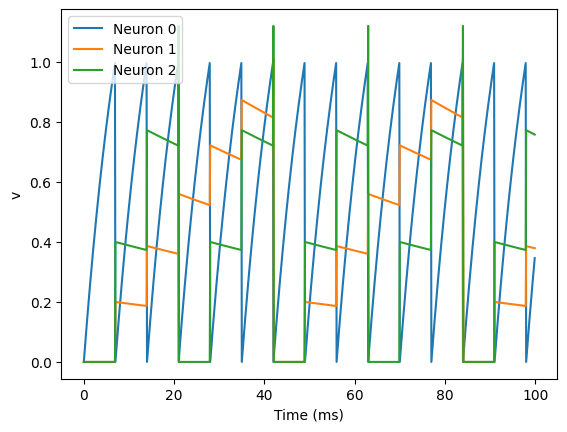

In [23]:
start_scope()

eqs = """
dv/dt = (I-v)/tau : 1
I : 1
tau : second
"""

neuron_group = NeuronGroup(3, eqs, threshold="v > 1", reset="v = 0", method="exact")
neuron_group.I = [2, 0, 0]
neuron_group.tau = [10, 100, 100] * ms

S = Synapses(neuron_group, neuron_group, "w : 1", on_pre="v_post += w") # Commenting out the instantiated Synapses results in neuron 1 not receiving any current; thus, it will not spike.
S.connect(i=0, j=[1, 2]) # Creates a synapse from neuron 0 to neuron 1 and 2
S.w = "j * 0.2"
state_monitor = StateMonitor(neuron_group, "v", record=True)

run(100*ms)

plt.plot(state_monitor.t/ms, state_monitor.v[0], label="Neuron 0")
plt.plot(state_monitor.t/ms, state_monitor.v[1], label="Neuron 1")
plt.plot(state_monitor.t/ms, state_monitor.v[2], label="Neuron 2")
plt.xlabel("Time (ms)")
plt.ylabel("v")
plt.legend()
stop()

In [24]:
start_scope()

neuron_group = NeuronGroup(3, eqs, threshold="v > 1", reset="v = 0", method="exact")
neuron_group.I = [2, 0, 0]
neuron_group.tau = [10, 100, 100] * ms

S = Synapses(neuron_group, neuron_group, "w : 1", on_pre="v_post += w") # Commenting out the instantiated Synapses results in neuron 1 not receiving any current; thus, it will not spike.
S.connect(i=0, j=[1, 2]) # Creates a synapse from neuron 0 to neuron 1 and 2
S.w = "j * 0.2"
S.delay = "j * 2*ms"
state_monitor = StateMonitor(neuron_group, "v", record=True)

run(50*ms)

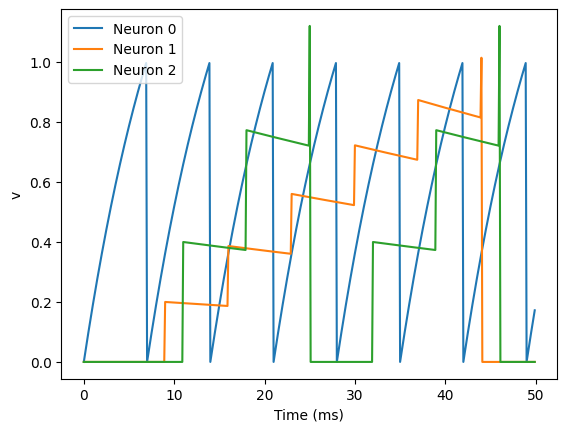

In [25]:
plt.plot(state_monitor.t/ms, state_monitor.v[0], label="Neuron 0")
plt.plot(state_monitor.t/ms, state_monitor.v[1], label="Neuron 1")
plt.plot(state_monitor.t/ms, state_monitor.v[2], label="Neuron 2")
plt.xlabel("Time (ms)")
plt.ylabel("v")
legend();

In [27]:
start_scope()

In [29]:
n = 10
neuron_group = NeuronGroup(n, "v:1")
synapses = Synapses(neuron_group, neuron_group)
synapses.connect("i!=j", p=0.2)

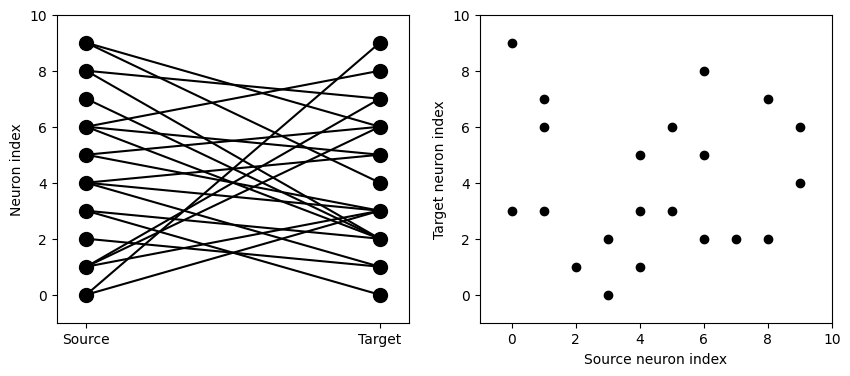

In [31]:
def visualize_connectivity(s):
    Ns = len(synapses.source)
    Nt = len(synapses.target)
    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.plot(np.zeros(Ns), np.arange(Ns), "ok", ms=10)
    plt.plot(np.ones(Nt), np.arange(Nt), "ok", ms=10)
    for i, j in zip(synapses.i, synapses.j):
        plt.plot([0, 1], [i, j], "-k")

    plt.xticks([0, 1], ["Source", "Target"])
    plt.ylabel("Neuron index")
    plt.xlim(-0.1, 1.1)
    plt.ylim(-1, max(Ns, Nt))
    plt.subplot(122)
    plt.plot(synapses.i, synapses.j, "ok")
    plt.xlim(-1, Ns)
    plt.ylim(-1, Nt)

    plt.xlabel("Source neuron index")
    plt.ylabel("Target neuron index")

visualize_connectivity(synapses)

In [33]:
start_scope()

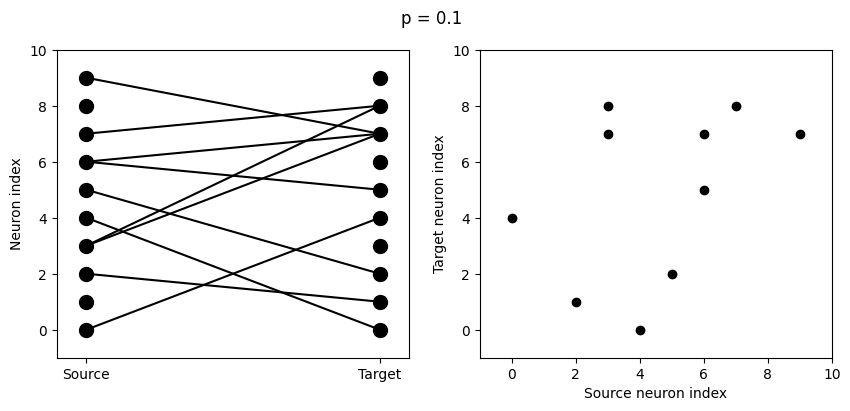

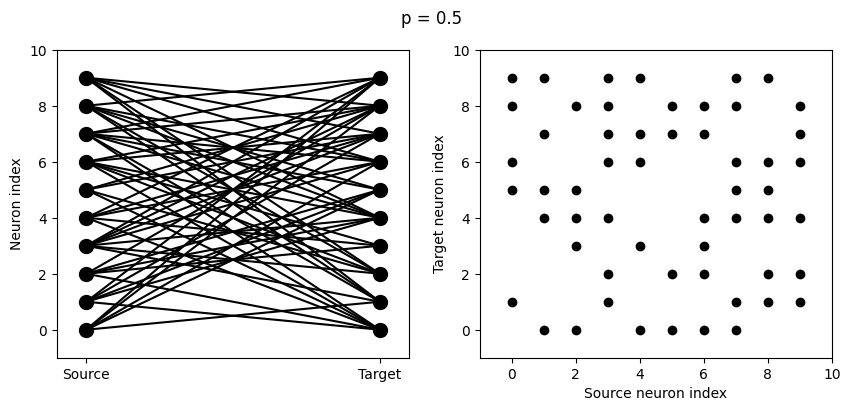

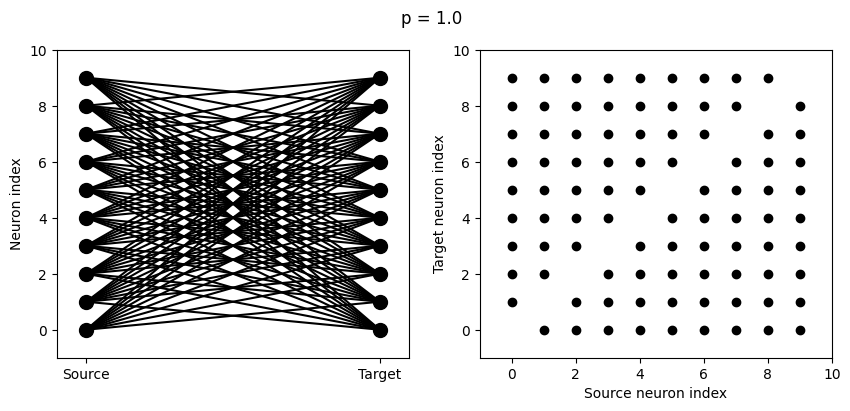

In [39]:
n = 10
g = NeuronGroup(n, "v:1")

for p in [0.1, 0.5, 1.0]:
    synapses = Synapses(g, g)
    synapses.connect("i!=j", p=p)
    visualize_connectivity(synapses)
    plt.suptitle(f"p = {p}")

In [40]:
start_scope()

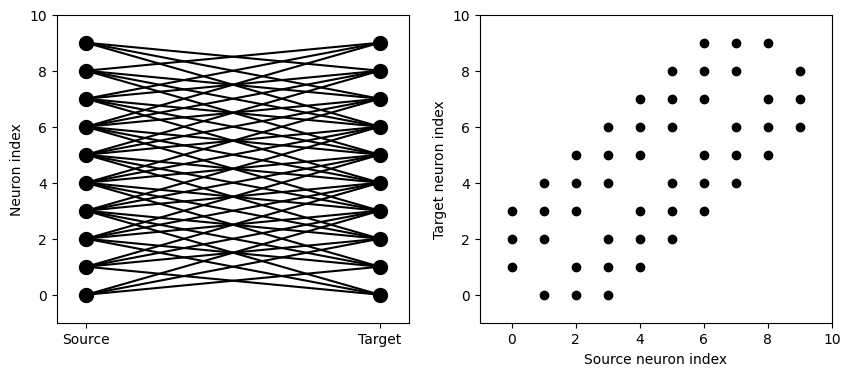

In [49]:
n = 10
g = NeuronGroup(n, "v:1")

synapses = Synapses(g, g)
synapses.connect(j="k for k in range(i -3, i+4) if i!=k", skip_if_invalid=True)
visualize_connectivity(synapses)

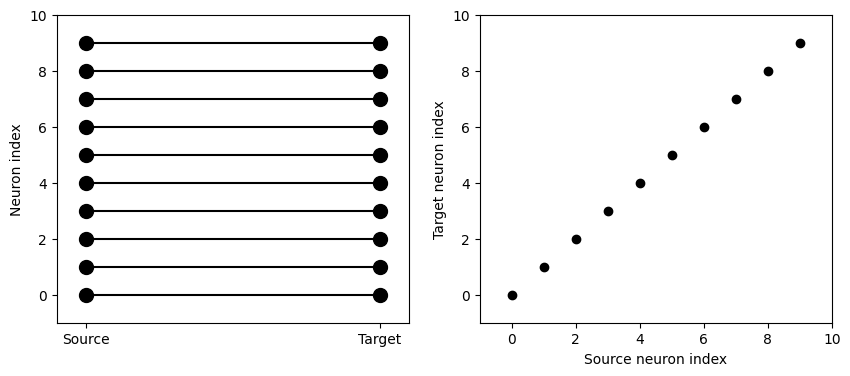

In [53]:
start_scope()

n = 10
neuron_group = NeuronGroup(n, "v:1")
synapses = Synapses(neuron_group, neuron_group)
synapses.connect(j="i")
visualize_connectivity(synapses)


In [54]:
start_scope()

In [55]:
n = 30
neuron_spacing = 30 * umetre
width = n/4.0*neuron_spacing


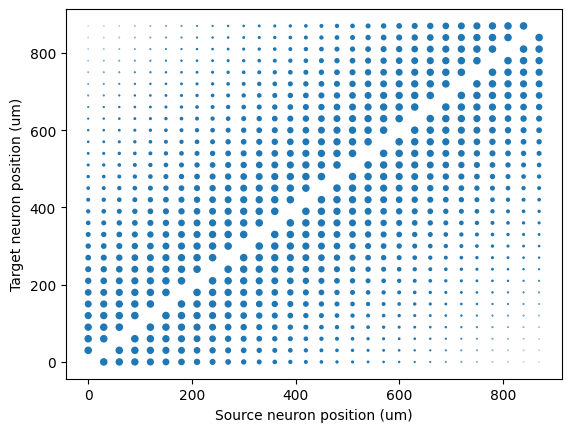

In [75]:
neuron_group = NeuronGroup(n, "x: metre")
neuron_group.x = "i*neuron_spacing"

synapses = Synapses(neuron_group, neuron_group, "w : 1")
synapses.connect(condition="i!=j")
synapses.w = "exp(-(x_pre-x_post)**2/(2*width**2))"

plt.scatter(synapses.x_pre/um, synapses.x_post/um, synapses.w*20)
plt.xlabel("Source neuron position (um)")
plt.ylabel("Target neuron position (um)");

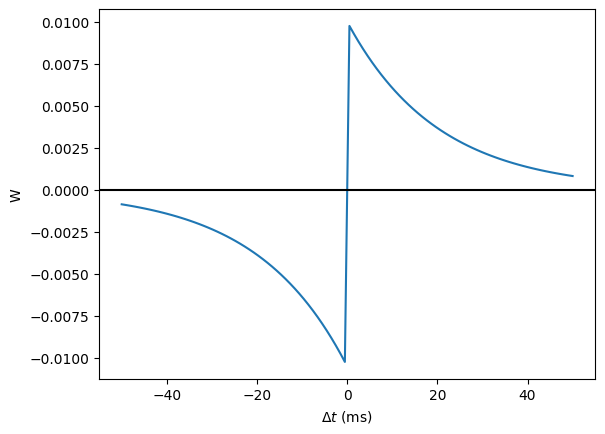

In [78]:
# Spike-Timing Dependent Plasticity (STDP)

tau_pre = tau_post = 20 * ms

A_pre = 0.01
A_post = -A_pre*1.05
delta_t = np.linspace(-50, 50, 100) * ms
W = np.where(delta_t>0, A_pre*np.exp(-delta_t/tau_pre), A_post*exp(delta_t/tau_post))
plt.plot(delta_t/ms, W)
plt.xlabel(r"$\Delta t$ (ms)")
plt.ylabel("W")
plt.axhline(0, ls="-", c="k");

In [79]:
start_scope()

In [81]:
tau_pre = tau_post = 20 * ms

wmax = 0.01
Apre = 0.01
Apost = -Apre*tau_pre/tau_post*1.05

neuron_group = NeuronGroup(1, "v:1", threshold="v>1", reset="")
synapses = Synapses(neuron_group, neuron_group, """
w: 1
dapre/dt = -apre/taupre : 1 (event-driven)
dapost/dt = -apost/taupost : 1 (event-driven)
""",
                    on_pre="""
                    v_post += w
                    apre += Apre
                    w = clip(w + apost, 0, wmax)
                    """,
                    on_post=
                    """
                    apost += Apost
                    w = clip(w + apre, 0, wmax)
                    """)

# clip(x, low, high) clamps x to a minimum of low to a maximum of high to avoid large negative or positive values.

In [82]:
start_scope()

In [96]:
tau_pre = tau_post = 20 * ms

wmax = 0.01
Apre = 0.01
Apost = -Apre*tau_pre/tau_post*1.05

neuron_group = NeuronGroup(2, "v:1", threshold="t>(1+i)*20*ms", refractory=100*ms)
synapses = Synapses(neuron_group, neuron_group, """
w: 1
dapre/dt = -apre/tau_pre : 1 (clock-driven)
dapost/dt = -apost/tau_post : 1 (clock-driven)
""",
                    on_pre="""
                    v_post += w
                    apre += Apre
                    w = clip(w + apost, 0, wmax)
                    """,
                    on_post=
                    """
                    apost += Apost
                    w = clip(w + apre, 0, wmax)
                    """, method="linear")

# clip(x, low, high) clamps x to a minimum of low to a maximum of high to avoid large negative or positive values.

synapses.connect(i=0, j=1)
state_monitor = StateMonitor(synapses, ["w", "apre", "apost"], record=True)

run(30*ms)


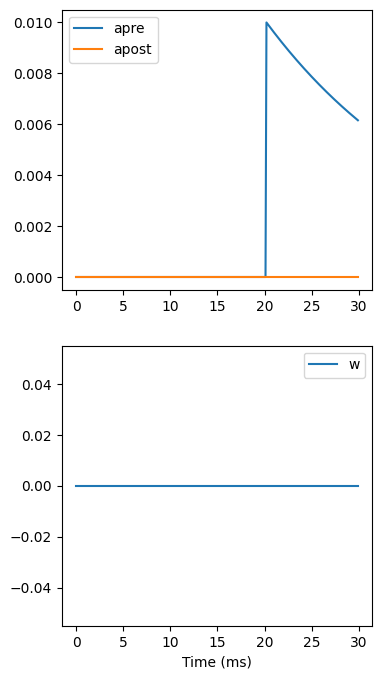

In [97]:
plt.figure(figsize=(4, 8))
plt.subplot(211)
plt.plot(state_monitor.t/ms, state_monitor.apre[0], label="apre")
plt.plot(state_monitor.t/ms, state_monitor.apost[0], label="apost")
plt.legend()

plt.subplot(212)
plt.plot(state_monitor.t/ms, state_monitor.w[0], label="w")
plt.legend(loc="best")
plt.xlabel("Time (ms)");